In [28]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Handling Imbalance
from imblearn.over_sampling import SMOTE

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [30]:
# 2. LOAD DATA (FRAUD DETECTION-Credit Card Fraud Dataset)
# ===============================

fraud_df = pd.read_csv('D:/TopMentor/Projects/Fraud Detection & Customer Segmentation/creditcard.csv')


In [31]:
print(fraud_df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [36]:
print(fraud_df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


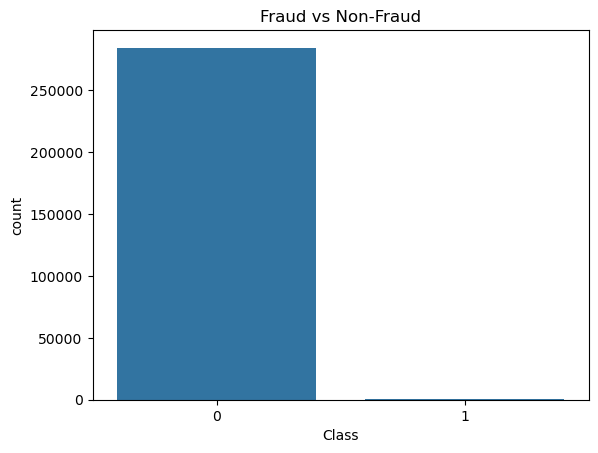

In [37]:
# Check imbalance
sns.countplot(x='Class', data=fraud_df)
plt.title('Fraud vs Non-Fraud')
plt.show()


In [38]:
# FEATURE & TARGET SPLIT
# ===============================

X = fraud_df.drop('Class', axis=1)
y = fraud_df['Class']

In [39]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [10]:
# HANDLE IMBALANCED DATA (SMOTE)
# ===============================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [56]:
#  MODEL TRAINING
# ===============================
# Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)

C:\Users\omkar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [41]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)


RandomForestClassifier(random_state=42)

In [57]:
# MODEL EVALUATION
# ===============================

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

In [43]:
# Evaluate both
print("\nLogistic Regression Results")
evaluate_model(lr, X_test, y_test)

print("\nRandom Forest Results")
evaluate_model(rf, X_test, y_test)


Logistic Regression Results
Confusion Matrix:
 [[56247   617]
 [    9    89]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.91      0.22        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.61     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC Score: 0.9756375397654842

Random Forest Results
Confusion Matrix:
 [[56847    17]
 [   17    81]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9644234399584257


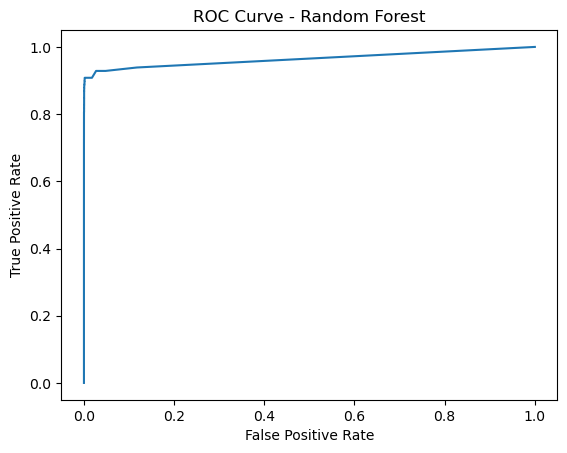

In [17]:
# ROC CURVE
# ===============================
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.show()


In [44]:
# THRESHOLD OPTIMIZATION
# ===============================
# Default threshold = 0.5
# Try custom threshold (important in fraud detection)
threshold = 0.3

y_pred_custom = (y_prob_rf > threshold).astype(int)

print("Custom Threshold Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

Custom Threshold Confusion Matrix:
 [[56826    38]
 [   11    87]]


In [45]:
# CUSTOMER SEGMENTATION (CLUSTERING)
# ===============================

# Load dataset (Mall Customers)
customer_df = pd.read_csv('D:/TopMentor/Projects/Fraud Detection & Customer Segmentation/Mall_Customers.csv')

print(customer_df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [46]:
# Select features
X_cluster = customer_df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [47]:
# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


C:\Users\omkar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\omkar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\omkar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\omkar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

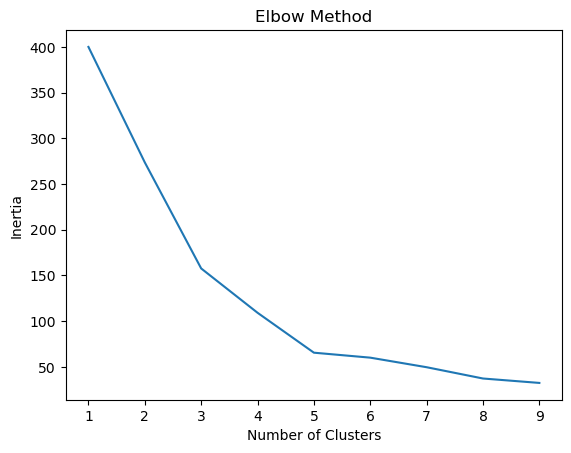

In [48]:
# FIND OPTIMAL K (ELBOW METHOD)
# ===============================
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K, inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()
    

In [52]:
# APPLY K-MEANS
# ===============================
print(customer_df.head())
print(customer_df.columns)

kmeans = KMeans(n_clusters=5, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster'],
      dtype='object')


C:\Users\omkar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


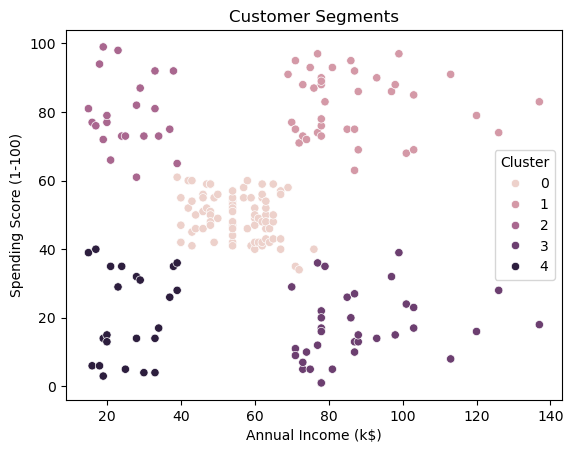

In [53]:
# VISUALIZATION
# ===============================
plt.figure()
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=customer_df
)
plt.title('Customer Segments')
plt.show()


In [55]:
# 14. BUSINESS INSIGHTS
# ===============================
# Example insights (interpret after seeing clusters):
# Cluster 0: High income, high spending -> Premium customers
# Cluster 1: Low income, low spending -> Budget customers
# Cluster 2: High income, low spending -> Target for marketing
